# Acne Segmentation — SegFormer + BCP + pseudo-labeling

In [1]:
# =========================

import os
import copy
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import SegformerForSemanticSegmentation


In [2]:
class AcneSegDataset(Dataset):
    def __init__(
        self,
        image_paths,
        images_dir,
        masks_dir,
        image_size=704,
        normalize=True,
        return_path=False,
    ):
        self.image_paths = image_paths
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.normalize = normalize
        self.return_path = return_path

        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.image_paths)

    def _get_mask_path(self, img_path):
        img_path = Path(img_path)
        mask_name = img_path.stem + ".png"
        return self.masks_dir / mask_name

    def __getitem__(self, idx):
        img_path = Path(self.image_paths[idx])
        mask_path = self._get_mask_path(img_path)

        img = cv2.imread(str(img_path))
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        mask = (mask > 127).astype(np.float32)

        img = img.astype(np.float32) / 255.0
        if self.normalize:
            img = (img - self.mean) / self.std

        img = np.transpose(img, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        if self.return_path:
            return img, mask, str(img_path)
        return img, mask


class UnlabeledAcneDataset(Dataset):
    def __init__(
        self,
        image_paths,
        image_size=704,
        normalize=True,
        return_path=False,
    ):
        self.image_paths = image_paths
        self.image_size = image_size
        self.normalize = normalize
        self.return_path = return_path

        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = Path(self.image_paths[idx])

        img = cv2.imread(str(img_path))
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)

        img = img.astype(np.float32) / 255.0
        if self.normalize:
            img = (img - self.mean) / self.std

        img = np.transpose(img, (2, 0, 1))
        img = torch.tensor(img, dtype=torch.float32)

        if self.return_path:
            return img, str(img_path)
        return img


In [27]:
# -------------------------
# Data paths + loaders
ROOT = "/kaggle/input/datasets/severynpel/acne04-v2/"
IMAGES_DIR = os.path.join(ROOT, "img_data/img_data")
MASKS_DIR = os.path.join(ROOT, "gt_masks/gt_masks")

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


all_image_paths = []
for fname in sorted(os.listdir(IMAGES_DIR)):
    ext = Path(fname).suffix.lower()
    if ext not in valid_exts:
        continue

    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, Path(fname).stem + ".png")

    if os.path.exists(mask_path):
        all_image_paths.append(img_path)

print(f"Found {len(all_image_paths)} image-mask pairs")


train_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))

IMG_SIZE = 640
BATCH_SIZE = 2
NUM_WORKERS = 2

train_dataset_lb = AcneSegDataset(
    image_paths=train_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=IMG_SIZE,
    normalize=True,
)
val_dataset_lb = AcneSegDataset(
    image_paths=val_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=IMG_SIZE,
    normalize=True,
)
test_dataset_lb = AcneSegDataset(
    image_paths=test_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=IMG_SIZE,
    normalize=True,
)

train_loader_lb = DataLoader(
    train_dataset_lb,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)
val_loader_lb = DataLoader(
    val_dataset_lb,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)
test_loader_lb = DataLoader(
    test_dataset_lb,
    batch_size=8,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

UNLABELED_BASE = "/kaggle/input/datasets/tiswan14/acne-dataset-image/AcneDataset"
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

candidate_folders = [
    ("train", "Papules"),
    ("train", "Pustules"),
    ("train", "Pustulus"),
    ("val", "Papules"),
    ("val", "Pustules"),
    ("val", "Pustulus"),
    ("test", "Papules"),
    ("test", "Pustules"),
    ("test", "Pustulus"),
]

unlabeled_paths = []
for split_name, class_name in candidate_folders:
    folder = os.path.join(UNLABELED_BASE, split_name, class_name)
    if os.path.isdir(folder):
        for root, _, files in os.walk(folder):
            for fname in files:
                if Path(fname).suffix.lower() in valid_exts:
                    unlabeled_paths.append(os.path.join(root, fname))

unlabeled_paths = sorted(list(set(unlabeled_paths)))

unlabeled_dataset = UnlabeledAcneDataset(
    image_paths=unlabeled_paths,
    image_size=IMG_SIZE,
    normalize=True,
)
unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)


Found 1204 image-mask pairs
Train: 963
Val: 120


In [5]:
next(iter(unlabeled_loader))[0].shape, next(iter(test_loader_lb))[0].shape

(torch.Size([3, 640, 640]), torch.Size([2, 3, 640, 640]))

In [4]:
# -------------------------
# Model

# -------------------------
class SegFormerBinarySeg(nn.Module):
    def __init__(self, model_name="nvidia/segformer-b2-finetuned-ade-512-512", dropout=0.1):
        super().__init__()
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            model_name,
            num_labels=1,
            ignore_mismatched_sizes=True,
        )
        if hasattr(self.model.decode_head, "dropout"):
            self.model.decode_head.dropout.p = dropout

    def forward(self, x):
        out = self.model(pixel_values=x)
        logits = out.logits
        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return logits


In [5]:
# -------------------------
# Losses + metrics

# -------------------------
def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    if logits.shape[-2:] != targets.shape[-2:]:
        logits = F.interpolate(logits, size=targets.shape[-2:], mode="bilinear", align_corners=False)

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)
    return iou.mean().item(), dice.mean().item()


def sigmoid_rampup(current, rampup_length=10):
    if rampup_length == 0:
        return 1.0
    current = np.clip(current, 0.0, rampup_length)
    phase = 1.0 - current / rampup_length
    return float(np.exp(-5.0 * phase * phase))


def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )
    return 1.0 - dice.mean()


def focal_loss_with_logits(logits, targets, alpha=0.25, gamma=2.0, reduction="mean"):
    probs = torch.sigmoid(logits)
    ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

    p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
    alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)
    loss = alpha_t * ((1.0 - p_t) ** gamma) * ce_loss

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    return loss


def focal_dice_loss(logits, targets, focal_weight=1.0, dice_weight=1.0, alpha=0.25, gamma=2.0):
    fl = focal_loss_with_logits(logits, targets, alpha=alpha, gamma=gamma)
    dl = dice_loss(logits, targets)
    return focal_weight * fl + dice_weight * dl


def masked_focal_dice_loss(
    logits,
    pseudo_probs,
    pos_thr=0.7,
    neg_thr=0.3,
    focal_weight=1.0,
    dice_weight=1.0,
    alpha=0.25,
    gamma=2.0,
    eps=1e-8,
):
    probs = torch.sigmoid(logits)

    pos_mask = (pseudo_probs > pos_thr).float()
    neg_mask = (pseudo_probs < neg_thr).float()
    conf_mask = pos_mask + neg_mask
    pseudo_targets = (pseudo_probs > 0.5).float()

    ce_loss = F.binary_cross_entropy_with_logits(logits, pseudo_targets, reduction="none")
    p_t = probs * pseudo_targets + (1.0 - probs) * (1.0 - pseudo_targets)
    alpha_t = alpha * pseudo_targets + (1.0 - alpha) * (1.0 - pseudo_targets)

    focal_map = alpha_t * ((1.0 - p_t) ** gamma) * ce_loss
    focal = (focal_map * conf_mask).sum() / (conf_mask.sum() + eps)

    probs_m = (probs * conf_mask).view(probs.size(0), -1)
    targets_m = (pseudo_targets * conf_mask).view(probs.size(0), -1)

    inter = (probs_m * targets_m).sum(dim=1)
    union = probs_m.sum(dim=1) + targets_m.sum(dim=1)
    dice = 1.0 - ((2.0 * inter + eps) / (union + eps)).mean()

    return focal_weight * focal + dice_weight * dice


In [6]:
# -------------------------
# Teacher / EMA helpers

# -------------------------
def create_teacher_from_student(student, teacher_device):
    teacher = copy.deepcopy(student).to(teacher_device)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher


@torch.no_grad()
def update_teacher(student, teacher, alpha=0.99):
    for t_param, s_param in zip(teacher.parameters(), student.parameters()):
        s_data = s_param.data.to(t_param.device, non_blocking=True)
        t_param.data.mul_(alpha).add_(s_data, alpha=(1.0 - alpha))


def cycle_loader(loader):
    while True:
        for batch in loader:
            yield batch


@torch.no_grad()
def generate_pseudo_mask(teacher, imgs, threshold=0.6, return_device=None):
    teacher.eval()
    teacher_device = next(teacher.parameters()).device

    imgs = imgs.to(teacher_device, non_blocking=True)

    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        logits = teacher(imgs)
        probs = torch.sigmoid(logits)

    pseudo = (probs > threshold).float()

    if return_device is not None:
        pseudo = pseudo.to(return_device, non_blocking=True)
        probs = probs.to(return_device, non_blocking=True)

    return pseudo, probs


In [7]:
# -------------------------
# BCP

# -------------------------
def copy_paste(src_img, src_mask, dst_img, dst_mask, patch_size=128):
    device = src_img.device

    B = min(src_img.size(0), dst_img.size(0))
    _, _, Hs, Ws = src_img.shape
    _, _, Hd, Wd = dst_img.shape

    out_img = dst_img.clone()
    out_mask = dst_mask.clone()

    half = patch_size // 2

    for b in range(B):
        mask = src_mask[b, 0]
        ys, xs = torch.where(mask > 0.5)

        if ys.numel() == 0:
            continue

        idx = torch.randint(0, ys.numel(), (1,), device=device).item()
        cy = ys[idx].item()
        cx = xs[idx].item()

        y1 = max(0, cy - half)
        y2 = min(Hs, cy + half)
        x1 = max(0, cx - half)
        x2 = min(Ws, cx + half)

        ph = y2 - y1
        pw = x2 - x1

        if ph < patch_size:
            if y1 == 0:
                y2 = min(Hs, y1 + patch_size)
            elif y2 == Hs:
                y1 = max(0, y2 - patch_size)

        if pw < patch_size:
            if x1 == 0:
                x2 = min(Ws, x1 + patch_size)
            elif x2 == Ws:
                x1 = max(0, x2 - patch_size)

        patch_img = src_img[b, :, y1:y2, x1:x2]
        patch_mask = src_mask[b, :, y1:y2, x1:x2]

        ph, pw = patch_img.shape[-2], patch_img.shape[-1]
        if ph <= 0 or pw <= 0:
            continue

        ph = min(ph, Hd)
        pw = min(pw, Wd)

        patch_img = patch_img[:, :ph, :pw]
        patch_mask = patch_mask[:, :ph, :pw]

        ry = 0 if Hd == ph else torch.randint(0, Hd - ph + 1, (1,), device=device).item()
        rx = 0 if Wd == pw else torch.randint(0, Wd - pw + 1, (1,), device=device).item()

        out_img[b, :, ry:ry + ph, rx:rx + pw] = patch_img
        out_mask[b, :, ry:ry + ph, rx:rx + pw] = torch.maximum(
            out_mask[b, :, ry:ry + ph, rx:rx + pw],
            patch_mask,
        )

    return out_img, out_mask


@torch.no_grad()
def bidirectional_copy_paste(
    l_img,
    l_mask,
    u_img,
    teacher,
    pseudo_threshold=0.6,
    patch_size=128,
):
    student_device = l_img.device
    pseudo_u, _ = generate_pseudo_mask(
        teacher,
        u_img,
        threshold=pseudo_threshold,
        return_device=student_device,
    )

    img_forward, mask_forward = copy_paste(
        src_img=l_img,
        src_mask=l_mask,
        dst_img=u_img,
        dst_mask=pseudo_u,
        patch_size=patch_size,
    )

    img_reverse, mask_reverse = copy_paste(
        src_img=u_img,
        src_mask=pseudo_u,
        dst_img=l_img,
        dst_mask=l_mask,
        patch_size=patch_size,
    )

    return img_forward, mask_forward, img_reverse, mask_reverse, pseudo_u


In [8]:
# -------------------------
# Train / val

# -------------------------
def train_one_epoch_semi(
    student,
    teacher,
    labeled_loader,
    unlabeled_loader,
    optimizer,
    student_device,
    teacher_device,
    ep,
    epochs,
    scaler,
    base_lambda_unsup=0.2,
    base_lambda_bcp=0.5,
    pseudo_threshold=0.6,
    ema_alpha=0.99,
    rampup_length=10,
    patch_size=128,
):
    student.train()
    teacher.eval()

    running_loss = 0.0
    running_sup_loss = 0.0
    running_unsup_loss = 0.0
    running_bcp_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    ramp = sigmoid_rampup(ep, rampup_length=rampup_length)
    lambda_unsup = base_lambda_unsup * ramp
    lambda_bcp = base_lambda_bcp * ramp

    unlabeled_iter = cycle_loader(unlabeled_loader)
    pbar = tqdm(labeled_loader, desc=f"epoch {ep+1}/{epochs}", leave=False)

    for imgs_l, masks_l in pbar:
        imgs_u = next(unlabeled_iter)
        if isinstance(imgs_u, (list, tuple)):
            imgs_u = imgs_u[0]

        imgs_l = imgs_l.to(student_device, non_blocking=True)
        masks_l = masks_l.to(student_device, non_blocking=True)
        imgs_u = imgs_u.to(student_device, non_blocking=True)

        b = min(imgs_l.size(0), masks_l.size(0), imgs_u.size(0))
        imgs_l = imgs_l[:b]
        masks_l = masks_l[:b]
        imgs_u = imgs_u[:b]

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits_l = student(imgs_l)
            loss_sup = focal_dice_loss(
                logits_l,
                masks_l,
                focal_weight=1.0,
                dice_weight=1.0,
                alpha=0.25,
                gamma=2.0,
            )

            with torch.no_grad():
                pseudo_u, pseudo_probs = generate_pseudo_mask(
                    teacher,
                    imgs_u.to(teacher_device, non_blocking=True),
                    threshold=pseudo_threshold,
                    return_device=student_device,
                )

            logits_u = student(imgs_u)
            loss_unsup = masked_focal_dice_loss(
                logits_u,
                pseudo_probs,
                pos_thr=0.7,
                neg_thr=0.3,
                focal_weight=1.0,
                dice_weight=1.0,
                alpha=0.25,
                gamma=2.0,
            )

            with torch.no_grad():
                img_f, mask_f, img_r, mask_r, _ = bidirectional_copy_paste(
                    imgs_l,
                    masks_l,
                    imgs_u,
                    teacher,
                    pseudo_threshold=pseudo_threshold,
                    patch_size=patch_size,
                )

            logits_f = student(img_f)
            logits_r = student(img_r)

            loss_f = focal_dice_loss(logits_f, mask_f, focal_weight=1.0, dice_weight=1.0)
            loss_r = focal_dice_loss(logits_r, mask_r, focal_weight=1.0, dice_weight=1.0)
            loss_bcp = 0.5 * (loss_f + loss_r)

            loss = loss_sup + lambda_unsup * loss_unsup + lambda_bcp * loss_bcp

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        update_teacher(student, teacher, alpha=ema_alpha)

        iou, dice = batch_iou_dice(logits_l.detach(), masks_l)

        running_loss += loss.item()
        running_sup_loss += loss_sup.item()
        running_unsup_loss += loss_unsup.item()
        running_bcp_loss += loss_bcp.item()
        running_iou += iou
        running_dice += dice

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            sup=f"{loss_sup.item():.4f}",
            unsup=f"{loss_unsup.item():.4f}",
            bcp=f"{loss_bcp.item():.4f}",
            dice=f"{dice:.4f}",
        )

    n = len(labeled_loader)
    return {
        "loss": running_loss / n,
        "sup_loss": running_sup_loss / n,
        "unsup_loss": running_unsup_loss / n,
        "bcp_loss": running_bcp_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "lambda_unsup": lambda_unsup,
        "lambda_bcp": lambda_bcp,
    }


@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss = focal_dice_loss(logits, masks)

        iou, dice = batch_iou_dice(logits, masks)
        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].plot(history["train_sup_loss"], label="train_sup_loss", linestyle="--")
    axes[0].plot(history["train_unsup_loss"], label="train_unsup_loss", linestyle="--")
    axes[0].plot(history["train_bcp_loss"], label="train_bcp_loss", linestyle="--")
    axes[0].set_title("Loss history")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history["train_dice"], label="train_dice")
    axes[1].plot(history["val_dice"], label="val_dice")
    axes[1].set_title("Dice history")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(history["train_iou"], label="train_iou")
    axes[2].plot(history["val_iou"], label="val_iou")
    axes[2].set_title("IoU history")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("IoU")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


In [9]:
# -------------------------
# Device setup

# -------------------------
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print("CUDA GPUs:", gpu_count)
    for i in range(gpu_count):
        print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")

    student_device = torch.device("cuda:0")
    teacher_device = torch.device("cuda:1") if gpu_count >= 2 else torch.device("cuda:0")
else:
    student_device = torch.device("cpu")
    teacher_device = torch.device("cpu")

print("student_device:", student_device)
print("teacher_device:", teacher_device)


CUDA GPUs: 2
  cuda:0 -> Tesla T4
  cuda:1 -> Tesla T4
student_device: cuda:0
teacher_device: cuda:1


In [10]:
# -------------------------
# Init models

# -------------------------
student_model = SegFormerBinarySeg(
    model_name="nvidia/segformer-b2-finetuned-ade-512-512",
).to(student_device)

SEGFORMER_ACNE_CKPT = "/kaggle/input/models/severynpel/acne-segformer/pytorch/default/1/best_segformer_acne.pt"
state_dict = torch.load(SEGFORMER_ACNE_CKPT, map_location="cpu")

if isinstance(state_dict, dict) and "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]
elif isinstance(state_dict, dict) and "model_state_dict" in state_dict:
    state_dict = state_dict["model_state_dict"]

state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

missing, unexpected = student_model.load_state_dict(state_dict, strict=False)
print("Loaded acne pretrained checkpoint:", SEGFORMER_ACNE_CKPT)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

teacher_model = create_teacher_from_student(student_model, teacher_device=teacher_device)

optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loaded acne pretrained checkpoint: /kaggle/input/models/severynpel/acne-segformer/pytorch/default/1/best_segformer_acne.pt
Missing keys: []
Unexpected keys: []


/tmp/ipykernel_55/1816807109.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
# -------------------------
# Experiment 2 training

# -------------------------
num_epochs = 45
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_sup_loss": [],
    "train_unsup_loss": [],
    "train_bcp_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_metrics = train_one_epoch_semi(
        student=student_model,
        teacher=teacher_model,
        labeled_loader=train_loader_lb,
        unlabeled_loader=unlabeled_loader,
        optimizer=optimizer,
        student_device=student_device,
        teacher_device=teacher_device,
        ep=epoch,
        epochs=num_epochs,
        scaler=scaler,
        base_lambda_unsup = 0.05,
        base_lambda_bcp = 0.1,
        rampup_length = 15,
        pseudo_threshold=0.75,
        ema_alpha=0.99,
        patch_size=100,
    )

    val_metrics = validate_one_epoch(
        model=student_model,
        loader=val_loader_lb,
        device=student_device,
    )

    history["train_loss"].append(train_metrics["loss"])
    history["train_sup_loss"].append(train_metrics["sup_loss"])
    history["train_unsup_loss"].append(train_metrics["unsup_loss"])
    history["train_bcp_loss"].append(train_metrics["bcp_loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"train_loss={train_metrics['loss']:.4f}, "
        f"sup={train_metrics['sup_loss']:.4f}, "
        f"unsup={train_metrics['unsup_loss']:.4f}, "
        f"bcp={train_metrics['bcp_loss']:.4f}, "
        f"train_iou={train_metrics['iou']:.4f}, "
        f"train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, "
        f"val_iou={val_metrics['iou']:.4f}, "
        f"val_dice={val_metrics['dice']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(student_model.state_dict(), "best_segformer_acne_semi_student_exp2_2gpu_amp.pth")
        torch.save(teacher_model.state_dict(), "best_segformer_acne_semi_teacher_exp2_2gpu_amp.pth")
        print("Saved best semi-supervised model.")

print(f"\nBest val Dice: {best_val_dice:.4f}")
plot_training_history(history)


epoch 1/45:   0%|          | 0/481 [00:00<?, ?it/s]

/tmp/ipykernel_55/1729807492.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_55/1680348864.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_55/1729807492.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch [1/45] | train_loss=0.4559, sup=0.4556, unsup=0.1993, bcp=0.4600, train_iou=0.4037, train_dice=0.5632 | val_loss=0.4843, val_iou=0.3770, val_dice=0.5326
Saved best semi-supervised model.


epoch 2/45:   0%|          | 0/481 [00:00<?, ?it/s]

Epoch [2/45] | train_loss=0.4216, sup=0.4208, unsup=0.2179, bcp=0.4490, train_iou=0.4364, train_dice=0.5975 | val_loss=0.4628, val_iou=0.3990, val_dice=0.5562
Saved best semi-supervised model.


...

epoch 35/45:   0%|          | 0/481 [00:00<?, ?it/s]

Epoch [35/45] | train_loss=0.2803, sup=0.2028, unsup=1.0000, bcp=0.2752, train_iou=0.6873, train_dice=0.8083 | val_loss=0.4830, val_iou=0.3822, val_dice=0.5408


epoch 36/45:   0%|          | 0/481 [00:00<?, ?it/s]

Epoch [36/45] | train_loss=0.2800, sup=0.2025, unsup=1.0000, bcp=0.2750, train_iou=0.6879, train_dice=0.8083 | val_loss=0.4720, val_iou=0.3955, val_dice=0.5544


epoch 37/45:   0%|          | 0/481 [00:00<?, ?it/s]

In [17]:

@torch.no_grad()
def evaluate_segmentation_metrics(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()
        tn = ((1 - preds) * (1 - masks)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
    }


{'accuracy': 0.994147237141927, 'precision': 0.5967812997184985, 'recall': 0.5558002957778828, 'iou': 0.40406275182452184, 'dice': 0.5755622407893933}


In [24]:
student_model.load_state_dict(torch.load("best_segformer_acne_semi_student_exp2_2gpu_amp.pth", map_location=student_device))
student_model.eval()


val_metrics = evaluate_segmentation_metrics(student_model, test_loader_lb, student_device)
print(val_metrics)

{'accuracy': 0.9960620117187499, 'precision': 0.6584373352867837, 'recall': 0.5573043478260659, 'iou': 0.43232042983630575, 'dice': 0.6036644047389786}


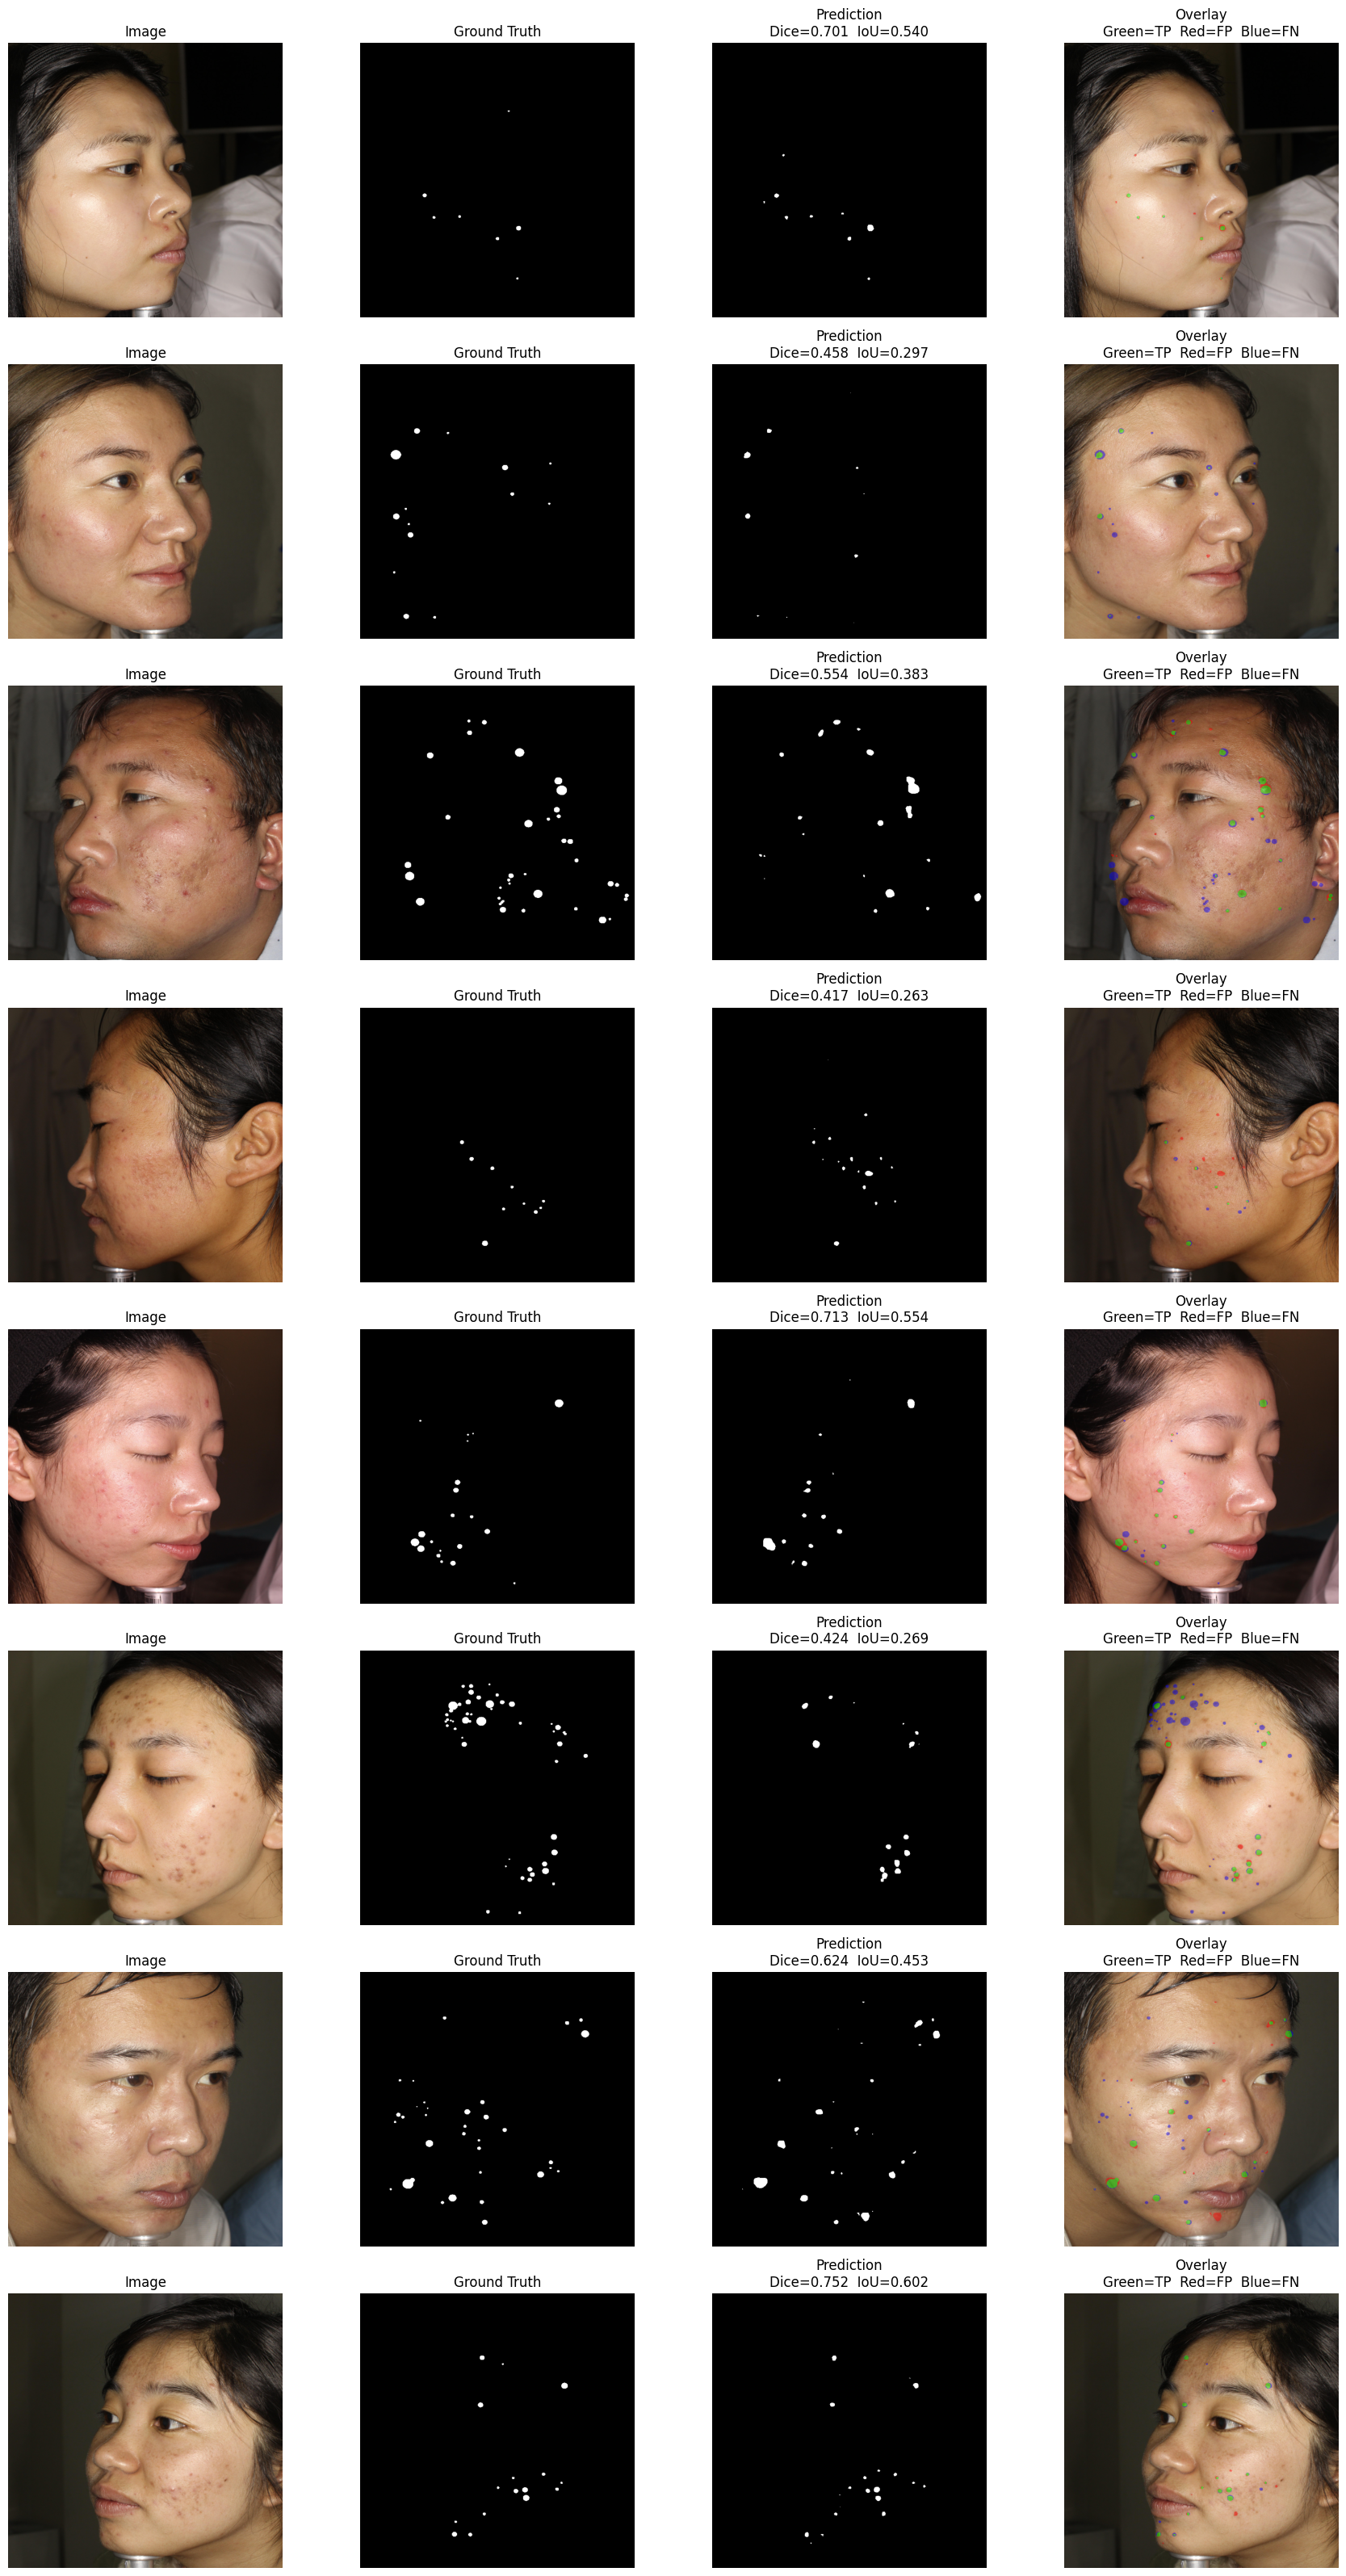

In [28]:
@torch.no_grad()
def get_predictions(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), probs.cpu(), preds.cpu()


def visualize_predictions_grid(imgs, masks, preds, n=4):
    n = min(n, len(imgs))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = denormalize_if_needed(imgs[i])
        gt = masks[i, 0].numpy()
        pred = preds[i, 0].numpy()

        dice, iou = compute_metrics_single(pred, gt)
        overlay = make_error_overlay(img, pred, gt, alpha=0.45)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice={dice:.3f}  IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay\nGreen=TP  Red=FP  Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

def denormalize_if_needed(img):
    """
    img: torch.Tensor [3, H, W] після ImageNet normalization
    return: numpy [H, W, 3] в діапазоні [0, 1]
    """
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().float().clone()

    # ImageNet stats
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # denormalize
    img = img * std + mean

    # clamp і в numpy
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()

    return img

def compute_metrics_single(pred, gt, eps=1e-8):
    """
    pred: [H, W]
    gt:   [H, W]
    """
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)

    return dice, iou


def make_error_overlay(img, pred, gt, alpha=0.45):
    """
    img: [H, W, 3] in [0,1]
    pred: [H, W] binary
    gt: [H, W] binary

    Colors:
      TP = green
      FP = red
      FN = blue
    """
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()

    # TP -> green
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])

    # FP -> red
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])

    # FN -> blue
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)

imgs, masks, probs, preds = get_predictions(student_model, test_loader_lb, student_device)
visualize_predictions_grid(imgs, masks, preds, n=10)